<a href="https://colab.research.google.com/github/mishraaashkacs242511-maker/Aashka/blob/main/T095_Aashka_Mishra_AI_Prac_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Path Discovered: Ginger Andheri MIDC -> NH48 Junction -> NH48 Merge (Mulund-Airoli) -> MIDC Industrial Area, Navi Mumbai -> Dahivati Tarf Boreti (NH166D) -> Imagicaa
Total Road Distance: 79.7 km



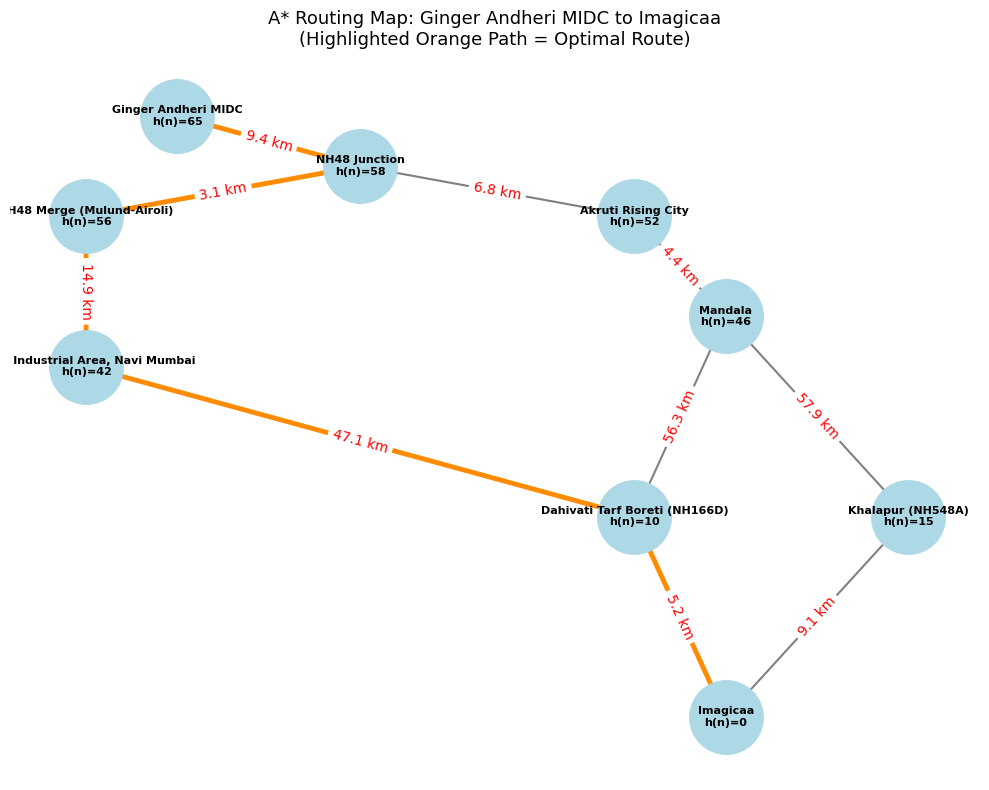

In [1]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'Ginger Andheri MIDC':              {'NH48 Junction': 9.4},
    'NH48 Junction':                    {'Akruti Rising City': 6.8, 'NH48 Merge (Mulund-Airoli)': 3.1},
    'Akruti Rising City':               {'Mandala': 4.4},
    'NH48 Merge (Mulund-Airoli)':       {'MIDC Industrial Area, Navi Mumbai': 14.9},
    'Mandala':                          {'Dahivati Tarf Boreti (NH166D)': 56.3, 'Khalapur (NH548A)': 57.9},
    'MIDC Industrial Area, Navi Mumbai':{'Dahivati Tarf Boreti (NH166D)': 47.1},
    'Dahivati Tarf Boreti (NH166D)':    {'Imagicaa': 5.2},
    'Khalapur (NH548A)':                {'Imagicaa': 9.1},
    'Imagicaa':                         {}
}

#h(n) from each node to Imagicaa
heuristics = {
    'Ginger Andheri MIDC': 65,
    'NH48 Junction': 58,
    'Akruti Rising City': 52,
    'NH48 Merge (Mulund-Airoli)': 56,
    'Mandala': 46,
    'MIDC Industrial Area, Navi Mumbai': 42,
    'Dahivati Tarf Boreti (NH166D)': 10,
    'Khalapur (NH548A)': 15,
    'Imagicaa': 0
}

node_positions = {
    'Ginger Andheri MIDC':               (2, 12),
    'NH48 Junction':                     (3, 11),
    'Akruti Rising City':                (4.5, 10),
    'NH48 Merge (Mulund-Airoli)':        (1.5, 10),
    'Mandala':                           (5, 8),
    'MIDC Industrial Area, Navi Mumbai': (1.5, 7),
    'Dahivati Tarf Boreti (NH166D)':     (4.5, 4),
    'Khalapur (NH548A)':                 (6, 4),
    'Imagicaa':                          (5, 0)
}

def a_star_search(graph, heuristics, start, goal):
    priority_queue = [(heuristics[start], start, [start], 0)]
    visited = set()

    while priority_queue:
        #F(n) = g(n) + h(n)
        f_score, current, path, g_score = heapq.heappop(priority_queue)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            return path, g_score

        for neighbor, edge_weight in graph[current].items():
            if neighbor not in visited:
                next_g = g_score + edge_weight
                next_f = next_g + heuristics[neighbor]
                heapq.heappush(priority_queue, (next_f, neighbor, path + [neighbor], next_g))

    return None, float('inf')

optimal_path, total_distance = a_star_search(graph, heuristics, 'Ginger Andheri MIDC', 'Imagicaa')
print(f"Optimal Path Discovered: {' -> '.join(optimal_path)}")
print(f"Total Road Distance: {total_distance} km\n")

G = nx.DiGraph()
for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(10, 8))

path_edges = list(zip(optimal_path, optimal_path[1:]))
normal_edges = [edge for edge in G.edges() if edge not in path_edges]

nx.draw_networkx_nodes(G, node_positions, node_size=2800, node_color='lightblue')
nx.draw_networkx_edges(G, node_positions, edgelist=normal_edges, width=1.5, edge_color='gray', arrows=True)

nx.draw_networkx_edges(G, node_positions, edgelist=path_edges, width=3.5, edge_color='darkorange', arrows=True)

node_labels = {node: f"{node}\nh(n)={heuristics[node]}" for node in G.nodes()}
nx.draw_networkx_labels(G, node_positions, labels=node_labels, font_size=8, font_weight='bold')

edge_labels = nx.get_edge_attributes(G, 'weight')
formatted_edge_labels = {k: f"{v} km" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, node_positions, edge_labels=formatted_edge_labels, font_color='red')

plt.title("A* Routing Map: Ginger Andheri MIDC to Imagicaa\n(Highlighted Orange Path = Optimal Route)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('A_star_Andheri_to_Imagicaa.png', dpi=150)
plt.show()
